# MNIST dataset

The following lines of code read the MNIST dataset if it was saved in the `../DataSets` directory:

In [1]:
import gzip
import os
import numpy as np

train_data = os.path.join("DataSets", "mnist", 
                          "train-images-idx3-ubyte.gz")
train_labels = os.path.join("DataSets", "mnist", "train-labels-idx1-ubyte.gz")

test_data = os.path.join("DataSets", "mnist", "t10k-images-idx3-ubyte.gz")
test_labels = os.path.join("DataSets", "mnist", "t10k-labels-idx1-ubyte.gz")

In [2]:
def mnist_images(filename):
    with gzip.open(filename, "rb") as file:
        data = np.frombuffer(file.read(), np.uint8, offset = 16)
        return data.reshape(-1, 28, 28) / 255
    
def mnist_labels(filename):
    with gzip.open(filename, "rb") as file:
        return np.frombuffer(file.read(), np.uint8, offset = 8)

X_train = mnist_images(train_data)
y_train = mnist_labels(train_labels)

X_test = mnist_images(test_data)
y_test = mnist_labels(test_labels)

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


The MNIST dataset contains different examples of handwritten digits (0-9). These are visualized in the following:

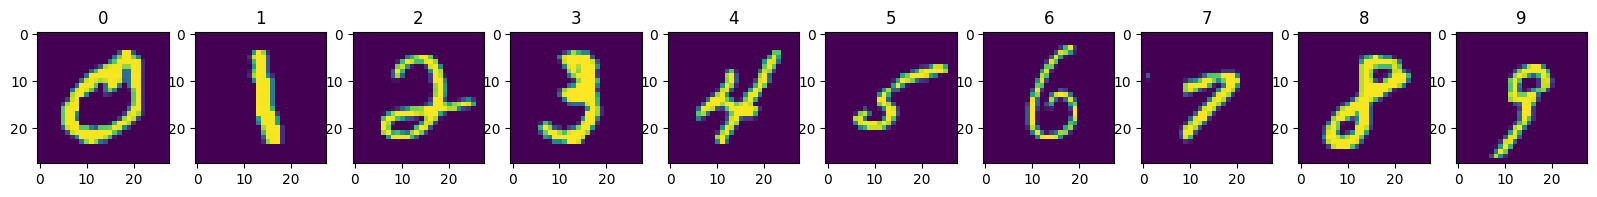

In [3]:
%matplotlib inline

import matplotlib.pyplot as plt

f,ax = plt.subplots(1,10)
f.set_size_inches(20,4)

for i in range(0,10):
    plt.sca(ax[i])
    plt.imshow(X_train[y_train==i,:,:][1])
    plt.title(i)


## Task

1. Develop a classifier that can distinguish between classes as well as possible. 
1. Examine the individual classes with respect to misclassifications. Which two classes are most often confused? 
1. Investigate the cause of the misclassifications. 
1. Is it useful to train a specialized classifier that is specifically trained on these two classes?

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ১. ডেটা ফ্ল্যাটেন করা (28x28 ইমেজকে 784 ডাইমেনশনে নেওয়া)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# ২. মডেল ট্রেনিং (Logistic Regression)
model = LogisticRegression(max_iter=100, multi_class='multinomial', solver='lbfgs')
model.fit(X_train_flat, y_train)

# ৩. প্রেডিকশন
y_pred = model.predict(X_test_flat)

print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.93      0.93       982
           5       0.91      0.88      0.89       892
           6       0.94      0.95      0.94       958
           7       0.94      0.92      0.93      1028
           8       0.87      0.88      0.88       974
           9       0.91      0.92      0.92      1009

    accuracy                           0.93     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000

/root/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (

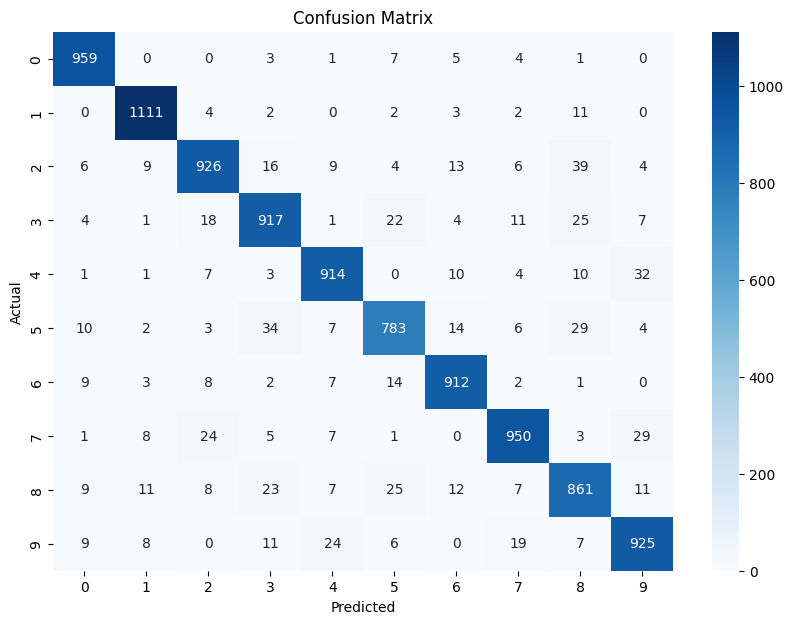

In [5]:
import matplotlib.pyplot as plt

# কনফিউশন ম্যাট্রিক্স তৈরি
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

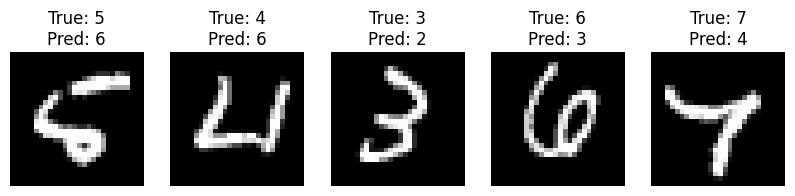

In [6]:
# ভুল প্রেডিকশনগুলো খুঁজে বের করা
misclassified_idx = np.where(y_pred != y_test)[0]

# প্রথম কয়েকটি ভুল ইমেজ দেখা
plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx[:5]):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"True: {y_test[idx]}\nPred: {y_pred[idx]}")
    plt.axis('off')
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=1e91bd54-be52-46c8-8e4a-baf88d675b91' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>